# ASKREDDIT (REDDIT MAY 2015) DATASET ANALYSIS


TO DO:
- add more advanced techniques (with NLP for analysis the content of the comments)
- add some plots/queries.

## Part 0: Creating the connection to Oracle

In [ ]:
from sqlalchemy.engine import create_engine
import oracledb
import polars as pl

# Change these parameters accordingly to match your needs
oradb_username  = "SYSTEM"
oradb_password  = ""
oradb_hostname  = "127.0.0.1"
oradb_port      = "1521"
oradb_service   = "FREE" 

# Create DSN with service name
dsn = f"{oradb_hostname}:{oradb_port}/{oradb_service}"

# Establish the connection
oradb_connection = oracledb.connect(user=oradb_username, password=oradb_password, dsn=dsn)
oradb_connection
oradb_cursor = oradb_connection.cursor()

##  Part 1: Creating the database

Below is the Oracle SQL DDL code that creates the database following the relational schema from the project. We first create “support” tables (those that do not reference others) such as AUTHOR, DISTINGUISHED, CONTROVERSY, REMOVAL, PARENT, and SUBREDDIT. Then we create the main COMMENT table (which references AUTHOR, CONTROVERSY, and SUBREDDIT) and finally the additional tables SCORE, IS_DISTINGUISHED, REMOVED, and DEPENDS that capture one-to-one or one-to-many relationships with COMMENT and the other entities.

Each table is created with an appropriate primary key and with foreign key constraints as indicated by the “#” symbols in the schema. 

In [ ]:
# 0. Suppression des tables si elles existent déjà pour éviter les conflits
statement = """
BEGIN
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_depends CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_removed CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_is_distinguished CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_score CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_comment CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_subreddit CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_parent CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_removal CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_controversy CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_distinguished CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
   BEGIN EXECUTE IMMEDIATE 'DROP TABLE askreddit_author CASCADE CONSTRAINTS'; EXCEPTION WHEN OTHERS THEN NULL; END;
END;
"""

oradb_cursor.execute(statement)


#### Create the simple (support) tables

In [ ]:
# Create the simple (support) tables

statement = [
    """
    CREATE TABLE askreddit_author (
        author_id NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
        author VARCHAR2(100) UNIQUE
    )""",
    
    """
    CREATE TABLE askreddit_distinguished (
        id NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
        distinguished VARCHAR2(50) UNIQUE
    )""",
    
    """
    CREATE TABLE askreddit_controversy (
        controversy_id NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
        controversiality NUMBER UNIQUE
    )""",
    
    """
    CREATE TABLE askreddit_removal (
        removal_id NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
        removal_reason VARCHAR2(100) UNIQUE
    )""",
    
    """
    CREATE TABLE askreddit_parent (
        parent_id VARCHAR2(50) PRIMARY KEY,
        link_id VARCHAR2(50)
    )""",
    
    """
    CREATE TABLE askreddit_subreddit (
        subreddit_id  VARCHAR2(50) PRIMARY KEY,
        subreddit VARCHAR2(100)
    )"""
]

for table in statement:
        oradb_cursor.execute(table)

### Create the main COMMENT table

In [43]:
# Create the main COMMENT table

statement = """
CREATE TABLE askreddit_comment (
    id VARCHAR2(255) PRIMARY KEY,                   -- String
    created_utc NUMBER(19),                         -- Int64 (Timestamp stored as number)
    name VARCHAR2(255),                             -- String
    body CLOB,                                      -- String
    edited NUMBER,                                  -- Int64 
    author_flair_css_class VARCHAR2(255),           -- String
    author_flair_text VARCHAR2(255),                -- String
    author VARCHAR2(255),                           -- String
    controversiality NUMBER,                        -- Int64
    subreddit_id VARCHAR2(255),                     -- String
    FOREIGN KEY (author) REFERENCES askreddit_author(author),
    FOREIGN KEY (controversiality) REFERENCES askreddit_controversy(controversiality),
    FOREIGN KEY (subreddit_id) REFERENCES askreddit_subreddit(subreddit_id)
)"""
oradb_cursor.execute(statement)

### Create the main SCORE table

In [47]:
#Create the SCORE table
#Note: SCORE.id is both the primary key of SCORE and a foreign key referencing COMMENT.id

statement = """
CREATE TABLE askreddit_score (
    id VARCHAR2(255) PRIMARY KEY,
    score NUMBER,
    ups NUMBER,
    downs NUMBER,
    score_hidden NUMBER,
    gilded NUMBER,
    FOREIGN KEY (id) REFERENCES askreddit_comment(id)
)"""
oradb_cursor.execute(statement)

### Create the linking tables

In [50]:
# Create the linking tables that express additional relationships

statement = [
    """
-- Table for the relationship between COMMENT and DISTINGUISHED.
-- A composite primary key is used because both attributes are foreign keys.
CREATE TABLE askreddit_is_distinguished (
    id VARCHAR2(255) PRIMARY KEY,
    distinguished VARCHAR2(50),
    FOREIGN KEY (id) REFERENCES askreddit_comment(id),
    FOREIGN KEY (distinguished) REFERENCES askreddit_distinguished(distinguished)
)""",

"""
-- Table for the relationship between COMMENT and REMOVAL.
CREATE TABLE askreddit_removed (
    id VARCHAR2(255) PRIMARY KEY,
    removal_reason VARCHAR2(255),
    FOREIGN KEY (id) REFERENCES askreddit_comment(id),
    FOREIGN KEY (removal_reason) REFERENCES askreddit_removal(removal_reason)
)""",

"""
-- Table for the dependency relationship between a COMMENT and its parent.
CREATE TABLE askreddit_depends (
    id VARCHAR2(255) PRIMARY KEY,
    parent_id  VARCHAR2(255),
    FOREIGN KEY (id) REFERENCES askreddit_comment(id),
    FOREIGN KEY (parent_id) REFERENCES askreddit_parent(parent_id)
    )"""
]

for table in statement:
        oradb_cursor.execute(table)

### Explanation

**Support Tables:**

Tables such as AUTHOR, DISTINGUISHED, CONTROVERSY, REMOVAL, PARENT, and SUBREDDIT are created first because they contain a single attribute (or a pair of attributes) and do not depend on any other table. Their primary keys are defined to ensure uniqueness.

**Main Table (COMMENT):**

The COMMENT table is central and stores all main comment information. It includes foreign keys referencing AUTHOR (for the comment’s author), CONTROVERSY (for the controversiality flag), and SUBREDDIT (to know which subreddit the comment belongs to).

**Dependent Tables:**

The SCORE table stores additional scoring information for each comment. Its primary key is the same as the comment’s id, and it is defined as a foreign key referencing COMMENT.
The IS_DISTINGUISHED and REMOVED tables capture additional attributes that in a normalized design might have been kept as part of the COMMENT table but here are separated to reduce redundancy and possibly speed up queries.
The DEPENDS table represents the “parent-child” relationship (a comment replying to another) by linking a comment’s id to a parent_id from the PARENT table.

**Data Types & Constraints:**

Data types such as VARCHAR2, NUMBER, DATE, and CLOB are chosen based on the expected nature of the data. Constraints (primary and foreign keys) are added to ensure referential integrity as defined in the relational schema.

## Part 2: : Loading the database 

### First, we have to read the CSV files:

In [ ]:
# Read CSV files
df_author = pl.read_csv("data/askreddit_author.csv")
df_comment = pl.read_csv("data/askreddit_comment.csv")
df_controverse = pl.read_csv("data/askreddit_controverse.csv")
df_depends = pl.read_csv("data/askreddit_depends.csv")
df_distinguished = pl.read_csv("data/askreddit_distinguihshed.csv")
df_is_distinguished = pl.read_csv("data/askreddit_is_distinguihshed.csv")
df_parent = pl.read_csv("data/askreddit_parent.csv")
df_removal = pl.read_csv("data/askreddit_removal.csv")
df_removed = pl.read_csv("data/askreddit_removed.csv")
df_score = pl.read_csv("data/askreddit_score.csv")
df_subreddit = pl.read_csv("data/askreddit_subreddit.csv")


Below, we display the number of rows in each csv file:

In [25]:
# Count the number of authors (assuming each row represents a unique author)
num_authors = df_author.height

# Count the number of comments (each row in the comment file is a comment)
num_comments = df_comment.height

# Count the number of controversial comments (assuming this dataframe has data on controversy)
num_controversies = df_controverse.height

# Count the number of dependencies (data about dependencies between comments or posts)
num_depends = df_depends.height

# Count the number of distinguished authors or users (data about distinguished users)
num_distinguised = df_distinguished.height

# Count the number of flags indicating distinguished authors (data indicating whether authors are distinguished)
num_is_distinguised = df_is_distinguished.height

# Count the number of parent-child relationships (data about parent-child relationships between comments)
num_parent = df_parent.height

# Count the number of removals (data about comment or post removal)
num_removal = df_removal.height

# Count the number of removed comments or posts (data about removed comments or posts)
num_removed = df_removed.height

# Count the number of scores (data about upvotes, downvotes, or other scoring metrics)
num_score = df_score.height

# Count the number of subreddits (data about the subreddits where comments or posts were made)
num_subreddit = df_subreddit.height

# Print the counts for all tables
print("Number of authors:", num_authors)
print("Number of comments:", num_comments)
print("Number of controversial comments:", num_controversies)
print("Number of dependencies:", num_depends)
print("Number of distinguished authors:", num_distinguised)
print("Number of distinguished flags:", num_is_distinguised)
print("Number of parent-child relationships:", num_parent)
print("Number of removals:", num_removal)
print("Number of removed comments/posts:", num_removed)
print("Number of scores:", num_score)
print("Number of subreddits:", num_subreddit)

Number of authors: 570735
Number of comments: 4234970
Number of controversial comments: 2
Number of dependencies: 4234970
Number of distinguished authors: 3
Number of distinguished flags: 4234970
Number of parent-child relationships: 1464558
Number of removals: 1
Number of removed comments/posts: 0
Number of scores: 4234970
Number of subreddits: 1


### Then, we create a method to import data from a dataframe to a table

In [ ]:
# I supply you with a method to import data from a dataframe to a table.
# For this to work, the field names of the table must match exactly with the column names of the dataframe
def write_to_db_manually(df_in:pl.DataFrame, conn, table_name, batch_size=10):
    # Get a cursor
    cursor = conn.cursor()
    columns = ",".join(df_in.columns)
    col_idx = ",".join([f":{item}" for item in df_in.columns])
    sql     = f"INSERT INTO {table_name}({columns}) VALUES ({col_idx})"
    rows = df_in.to_struct().to_list()
    cursor.executemany(sql, rows)
    conn.commit()

### Finally, with Python, using the dataframes created in earlier, we export them to the tables we have just created above.

#### Load the simple (support) tables

In [28]:
# Write each dataframe to the database
write_to_db_manually(df_author, oradb_connection, "askreddit_author")

In [29]:
write_to_db_manually(df_distinguished, oradb_connection, "askreddit_distinguished")

In [30]:
write_to_db_manually(df_controverse, oradb_connection, "askreddit_controversy")

In [31]:
write_to_db_manually(df_removal, oradb_connection, "askreddit_removal")

In [36]:
write_to_db_manually(df_parent, oradb_connection, "askreddit_parent")

In [37]:
write_to_db_manually(df_subreddit, oradb_connection, "askreddit_subreddit")

#### Load the main COMMENT table

In [44]:
write_to_db_manually(df_comment, oradb_connection, "askreddit_comment")

#### Load the main SCORE table

In [48]:
write_to_db_manually(df_score, oradb_connection, "askreddit_score")

#### Load the linking tables

In [51]:
write_to_db_manually(df_depends, oradb_connection, "askreddit_depends")

In [52]:
write_to_db_manually(df_is_distinguished, oradb_connection, "askreddit_is_distinguished")

For the removed table, we first clean the columns of the data frame as there are spaces in the columns names, and this is not desirable.

In [ ]:
df_removed = df_removed.rename({col: col.strip() for col in df_removed.columns})  # Remove spaces in the column names

Then, as we have seen, this dataset is empty. In order to push it in oracle, we need to enter default values.
To do so, we decide to use the first id of the comment database by default and the first removal reason of the removal table.

In [64]:
query = """
SELECT id FROM askreddit_comment FETCH FIRST 1 ROW ONLY
"""
pl.read_database(query, oradb_cursor)

ID
str
"""cqug90j"""


In [86]:
query = """
SELECT removal_reason FROM askreddit_removal FETCH FIRST 1 ROW ONLY
"""
pl.read_database(query, oradb_cursor)

REMOVAL_REASON
str
"""legal"""


In [89]:
# If the DataFrame is empty, we can add default rows to it
if df_removed.height == 0:
    df_removed = df_removed.vstack(pl.DataFrame({
        "id": ["cqug90j"],
        "removal_reason": ["legal"]
    }))

print(df_removed)


shape: (1, 2)
┌─────────┬────────────────┐
│ id      ┆ removal_reason │
│ ---     ┆ ---            │
│ str     ┆ str            │
╞═════════╪════════════════╡
│ cqug90j ┆ legal          │
└─────────┴────────────────┘


We can now push the table in Oracle:

In [90]:
write_to_db_manually(df_removed, oradb_connection, "askreddit_removed")

Below, we display the number of rows in each SQL table created:

In [91]:
query = """
SELECT COUNT(*) AS author_count 
FROM askreddit_author
"""
pl.read_database(query, oradb_cursor)

AUTHOR_COUNT
i64
570735


In [92]:
query = """
SELECT COUNT(*) AS distinguished_author_count 
FROM askreddit_distinguished
"""
pl.read_database(query, oradb_cursor)

DISTINGUISHED_AUTHOR_COUNT
i64
3


In [93]:
query = """
SELECT COUNT(*) AS controversial_comments_count 
FROM askreddit_controversy
"""
pl.read_database(query, oradb_cursor)

CONTROVERSIAL_COMMENTS_COUNT
i64
2


In [95]:
query = """
SELECT COUNT(*) AS removals_count 
FROM askreddit_removal
"""
pl.read_database(query, oradb_cursor)

REMOVALS_COUNT
i64
1


In [96]:
query = """
SELECT COUNT(*) AS parents_count 
FROM askreddit_parent
"""
pl.read_database(query, oradb_cursor)

PARENTS_COUNT
i64
1464558


In [97]:
query = """
SELECT COUNT(*) AS subreddit_count 
FROM askreddit_subreddit
"""
pl.read_database(query, oradb_cursor)

SUBREDDIT_COUNT
i64
1


In [98]:
query = """
SELECT COUNT(*) AS comments_count 
FROM askreddit_comment
"""
pl.read_database(query, oradb_cursor)

COMMENTS_COUNT
i64
4234970


In [99]:
query = """
SELECT COUNT(*) AS score_count 
FROM askreddit_score
"""
pl.read_database(query, oradb_cursor)

SCORE_COUNT
i64
4234970


In [100]:
query = """
SELECT COUNT(*) AS dependencies_count 
FROM askreddit_depends
"""
pl.read_database(query, oradb_cursor)

DEPENDENCIES_COUNT
i64
4234970


In [102]:
query = """
SELECT COUNT(*) AS distinguished_flags_count 
FROM askreddit_is_distinguished
"""
pl.read_database(query, oradb_cursor)

DISTINGUISHED_FLAGS_COUNT
i64
4234970


In [103]:
query = """
SELECT COUNT(*) AS removed_count 
FROM askreddit_removed
"""
pl.read_database(query, oradb_cursor)

REMOVED_COUNT
i64
1


All the rows count correspond to the ones we had from the csv files, except for the last table where we had to create one default entry to push the data in oracle.

## Verifying foreign key relationships

1. Check for Orphaned Records:  we do an example for the count of valid foreign key matches for askreddit_removed.id

In [ ]:
query = """ 
SELECT r.id 
FROM askreddit_removed r
LEFT JOIN askreddit_comment c ON r.id = c.id
WHERE c.id IS NULL
"""  

df_orphans = pl.read_database(query, oradb_cursor)
print(df_orphans)


shape: (0, 1)
┌──────┐
│ ID   │
│ ---  │
│ null │
╞══════╡
└──────┘


No rows in the output: this means all ids in askreddit_removed exist in askreddit_comment.



2. Check for Missing Foreign Key Values in Parent Table

In [7]:
query = """
SELECT DISTINCT r.id 
FROM askreddit_removed r
WHERE NOT EXISTS (
    SELECT 1 FROM askreddit_comment c WHERE c.id = r.id
)
"""
pl.read_database(query, oradb_cursor)   

ID
null


No rows in the output: this means all ids in askreddit_removed exist in askreddit_comment.

3. Verify Foreign Key Constraints in the Database

In [9]:
query = """
SELECT c.constraint_name, c.table_name, c.column_name, u.r_constraint_name 
FROM user_cons_columns c
JOIN user_constraints u ON c.constraint_name = u.constraint_name
WHERE u.constraint_type = 'R' 
AND c.table_name = 'ASKREDDIT_REMOVED'
"""

df_constraints = pl.read_database(query, oradb_cursor)
print(df_constraints)


shape: (2, 4)
┌─────────────────┬───────────────────┬────────────────┬───────────────────┐
│ CONSTRAINT_NAME ┆ TABLE_NAME        ┆ COLUMN_NAME    ┆ R_CONSTRAINT_NAME │
│ ---             ┆ ---               ┆ ---            ┆ ---               │
│ str             ┆ str               ┆ str            ┆ str               │
╞═════════════════╪═══════════════════╪════════════════╪═══════════════════╡
│ SYS_C008597     ┆ ASKREDDIT_REMOVED ┆ ID             ┆ SYS_C008587       │
│ SYS_C008598     ┆ ASKREDDIT_REMOVED ┆ REMOVAL_REASON ┆ SYS_C008556       │
└─────────────────┴───────────────────┴────────────────┴───────────────────┘


The output confirms that foreign key constraints exist on askreddit_removed. 


*SYS_C008597*: The id column in askreddit_removed references another table (most likely askreddit_comment).
*SYS_C008598*: The removal_reason column in askreddit_removed references another table (most likely askreddit_removal).
Since Oracle auto-generates constraint names (SYS_C...), it's harder to read. So we can check which tables they reference using:



In [10]:
query = """
SELECT u.constraint_name, u.table_name, u.r_constraint_name, p.table_name AS referenced_table
FROM user_constraints u
JOIN user_constraints p ON u.r_constraint_name = p.constraint_name
WHERE u.constraint_name IN ('SYS_C008597', 'SYS_C008598')
"""

df_constraints = pl.read_database(query, oradb_cursor)
print(df_constraints)


shape: (2, 4)
┌─────────────────┬───────────────────┬───────────────────┬───────────────────┐
│ CONSTRAINT_NAME ┆ TABLE_NAME        ┆ R_CONSTRAINT_NAME ┆ REFERENCED_TABLE  │
│ ---             ┆ ---               ┆ ---               ┆ ---               │
│ str             ┆ str               ┆ str               ┆ str               │
╞═════════════════╪═══════════════════╪═══════════════════╪═══════════════════╡
│ SYS_C008597     ┆ ASKREDDIT_REMOVED ┆ SYS_C008587       ┆ ASKREDDIT_COMMENT │
│ SYS_C008598     ┆ ASKREDDIT_REMOVED ┆ SYS_C008556       ┆ ASKREDDIT_REMOVAL │
└─────────────────┴───────────────────┴───────────────────┴───────────────────┘


Given the output, everything is correct.

##  Part 3: Initial exploration of the database 

1.  Retrieve a Sample of Recent Comments

In [16]:
query = """
SELECT id, created_utc, name, body, author
FROM askreddit_comment
ORDER BY created_utc DESC
FETCH FIRST 10 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 5)
┌─────────┬─────────────┬────────────┬─────────────────────────────────┬─────────────────────┐
│ ID      ┆ CREATED_UTC ┆ NAME       ┆ BODY                            ┆ AUTHOR              │
│ ---     ┆ ---         ┆ ---        ┆ ---                             ┆ ---                 │
│ str     ┆ i64         ┆ str        ┆ object                          ┆ str                 │
╞═════════╪═════════════╪════════════╪═════════════════════════════════╪═════════════════════╡
│ crrbeop ┆ 1433116799  ┆ t1_crrbeop ┆ classy way to put it            ┆ NotByAnyMeans       │
│ crrbenh ┆ 1433116797  ┆ t1_crrbenh ┆ Give them to Irish people in e… ┆ bellypouch          │
│ crrbemp ┆ 1433116796  ┆ t1_crrbemp ┆ people who cannot make up thei… ┆ torianicole731      │
│ crrbelu ┆ 1433116795  ┆ t1_crrbelu ┆ Does the sun set in the west/r… ┆ monster860          │
│ crrbelv ┆ 1433116795  ┆ t1_crrbelv ┆ Coffee.                         ┆ jsimo36             │
│ crrbelf ┆ 1433116794  ┆ t1_crrbel

This query fetches the 10 most recent comments (based on created_utc). 
It’s useful for a quick glance at the data stored in the comments table.

2. Comments per Subreddit

In [ ]:
query = """
SELECT s.subreddit, COUNT(c.id) AS nb_comments
FROM askreddit_comment c
JOIN askreddit_subreddit s ON c.subreddit_id = s.subreddit_id
GROUP BY s.subreddit
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (1, 2)
┌───────────┬─────────────┐
│ SUBREDDIT ┆ NB_COMMENTS │
│ ---       ┆ ---         │
│ str       ┆ i64         │
╞═══════════╪═════════════╡
│ AskReddit ┆ 4234970     │
└───────────┴─────────────┘


This query aggregates the number of comments per subreddit by joining the askreddit_comment and askreddit_subreddit tables.

3. Comments per Author

In [22]:
query = """
SELECT a.author, COUNT(c.id) AS nb_comments
FROM askreddit_comment c
JOIN askreddit_author a ON c.author = a.author
GROUP BY a.author
ORDER BY nb_comments DESC
FETCH FIRST 10 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 2)
┌─────────────────────┬─────────────┐
│ AUTHOR              ┆ NB_COMMENTS │
│ ---                 ┆ ---         │
│ str                 ┆ i64         │
╞═════════════════════╪═════════════╡
│ [deleted]           ┆ 312007      │
│ AutoModerator       ┆ 36910       │
│ Late_Night_Grumbler ┆ 8298        │
│ BiagioLargo         ┆ 5843        │
│ -_-Equinox666-_-    ┆ 2989        │
│ KubrickIsMyCopilot  ┆ 2601        │
│ Megaross            ┆ 2479        │
│ Asdyc               ┆ 2387        │
│ NaturalInclination  ┆ 2380        │
│ KeganRhode          ┆ 2377        │
└─────────────────────┴─────────────┘


This query lists the 10 first authors along with the count of comments they’ve posted, sorted in descending order to show the most active authors first.

4. Top 10 Comments by Score

In [27]:
query = """
SELECT c.id, c.body, s.score, s.ups, s.downs, s.gilded
FROM askreddit_comment c
JOIN askreddit_score s ON c.id = s.id
ORDER BY s.score DESC
FETCH FIRST 10 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 6)
┌─────────┬─────────────────────────────────┬───────┬──────┬───────┬────────┐
│ ID      ┆ BODY                            ┆ SCORE ┆ UPS  ┆ DOWNS ┆ GILDED │
│ ---     ┆ ---                             ┆ ---   ┆ ---  ┆ ---   ┆ ---    │
│ str     ┆ object                          ┆ i64   ┆ i64  ┆ i64   ┆ i64    │
╞═════════╪═════════════════════════════════╪═══════╪══════╪═══════╪════════╡
│ cr56nez ┆ Then you got yourself a one ni… ┆ 6761  ┆ 6761 ┆ 0     ┆ 2      │
│ cr5gn52 ┆ if it's untreated wood...       ┆ 6736  ┆ 6736 ┆ 0     ┆ 1      │
│         ┆                                 ┆       ┆      ┆       ┆        │
│         ┆ cut…                            ┆       ┆      ┆       ┆        │
│ cr3imvn ┆ I have family who sailed aroun… ┆ 5992  ┆ 5992 ┆ 0     ┆ 1      │
│ cr8p5z9 ┆ My boss is this giddy Asian la… ┆ 5927  ┆ 5927 ┆ 0     ┆ 0      │
│ cqxx3fj ┆ Thanks man and also fuck you m… ┆ 5849  ┆ 5849 ┆ 0     ┆ 0      │
│ crl2axg ┆ This happened in med school.  … ┆ 584

It helps identify the most popular or impactful comments by looking at their scoring details.

5. Count of Edited Comments

In [31]:
query = """
SELECT COUNT(*) AS edited_comments
FROM askreddit_comment
WHERE edited IS NOT NULL AND edited <> 0
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (1, 1)
┌─────────────────┐
│ EDITED_COMMENTS │
│ ---             │
│ i64             │
╞═════════════════╡
│ 80620           │
└─────────────────┘


This query gives an idea of how many comments have been edited compared to the total number.

6. Count of Comments with a Gilded Score

In [32]:
query = """
SELECT COUNT(*) AS gilded_comments
FROM askreddit_score
WHERE gilded > 0
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (1, 1)
┌─────────────────┐
│ GILDED_COMMENTS │
│ ---             │
│ i64             │
╞═════════════════╡
│ 2991            │
└─────────────────┘


It helps determine the level of community recognition (gilding) among the comments.

7. Distribution of Comments by Day

In [33]:
query = """
SELECT TRUNC(created_utc) AS comment_date, COUNT(*) AS nb_comments
FROM askreddit_comment
GROUP BY TRUNC(created_utc)
ORDER BY comment_date
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (2_035_708, 2)
┌──────────────┬─────────────┐
│ COMMENT_DATE ┆ NB_COMMENTS │
│ ---          ┆ ---         │
│ i64          ┆ i64         │
╞══════════════╪═════════════╡
│ 1430438400   ┆ 3           │
│ 1430438401   ┆ 2           │
│ 1430438402   ┆ 4           │
│ 1430438403   ┆ 5           │
│ 1430438404   ┆ 5           │
│ …            ┆ …           │
│ 1433116794   ┆ 1           │
│ 1433116795   ┆ 2           │
│ 1433116796   ┆ 1           │
│ 1433116797   ┆ 1           │
│ 1433116799   ┆ 1           │
└──────────────┴─────────────┘


Using Oracle’s TRUNC function on the date, we get the number of comments per day. 
This is useful for observing trends or peaks in activity.

We decide to plot the date distribution, the dates values are in Unix epoch time format (seconds since January 1, 1970). We need to convert them to readable dates before plotting.
We also aggregate the data by day for better visualisation.

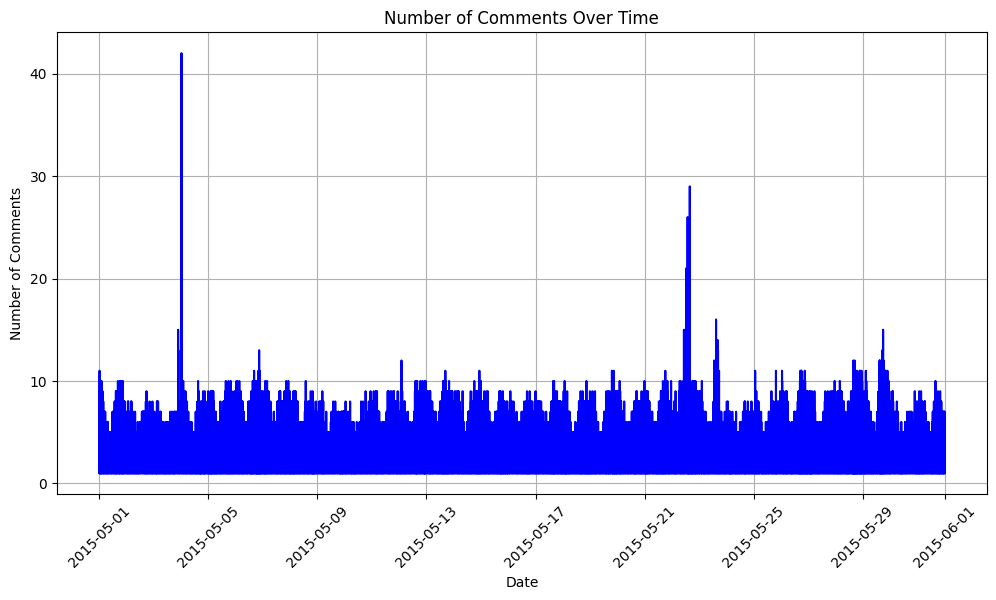

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to Pandas for easier plotting
df = result.to_pandas()

# Ensure 'comment_date' is a datetime type
df['comment_date'] = pd.to_datetime(df['COMMENT_DATE'], unit='s')

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df['comment_date'], df['NB_COMMENTS'], color='b')

# Labels and title
plt.xlabel("Date")
plt.ylabel("Number of Comments")
plt.title("Number of Comments Over Time")
plt.xticks(rotation=45)
plt.grid(True)

# Show the plot
plt.show()

The distribution seems to be quite the same everyday. There are however some big spikes.

8. Average Comment Score

In [109]:
query = """SELECT AVG(score) AS average_comment_score
FROM askreddit_score
"""
result = pl.read_database(query, oradb_cursor)
print(result)

shape: (1, 1)
┌───────────────────────┐
│ AVERAGE_COMMENT_SCORE │
│ ---                   │
│ f64                   │
╞═══════════════════════╡
│ 12.606224             │
└───────────────────────┘


It provides a general measure of the overall reception of comments by calculating their average score.

9. Average Comment Score by day

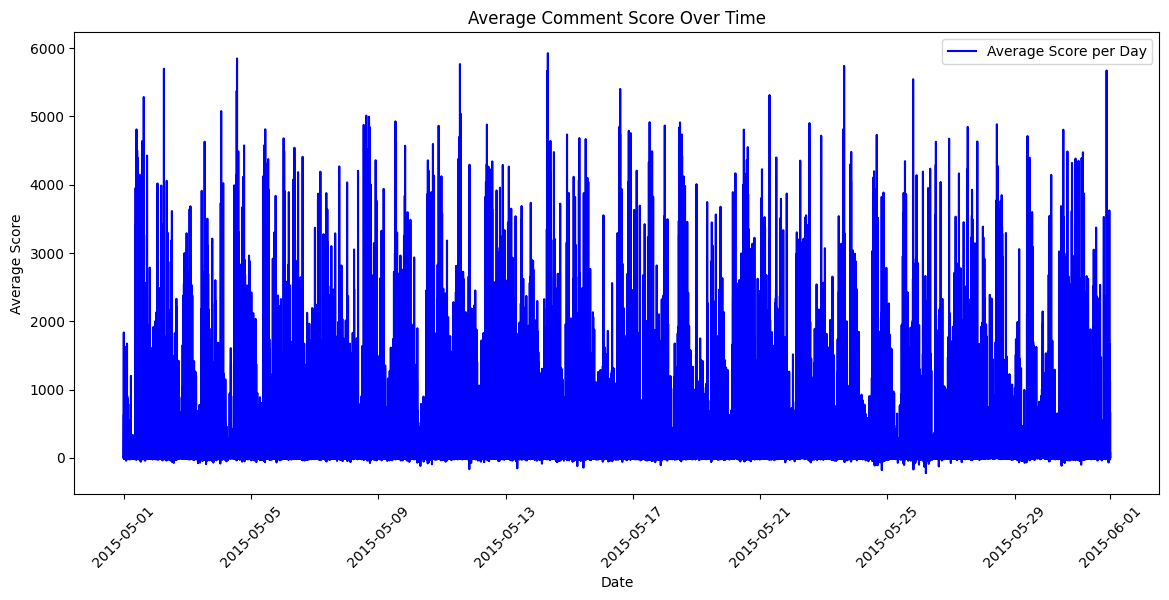

In [113]:
# Step 1: Execute the SQL query
query = """
SELECT TRUNC(c.created_utc) AS comment_date, AVG(s.score) AS avg_score
FROM askreddit_comment c
JOIN askreddit_score s ON c.id = s.id
GROUP BY TRUNC(c.created_utc)
ORDER BY comment_date
"""

# Step 2: Retrieve and convert data to Pandas
result = pl.read_database(query, oradb_cursor)
df = result.to_pandas()

# Step 3: Convert Unix timestamps to datetime
df['comment_date'] = pd.to_datetime(df['COMMENT_DATE'], unit='s')

# Step 4: Plot the data
plt.figure(figsize=(14,6))
plt.plot(df['comment_date'], df['AVG_SCORE'], color='b', label="Average Score per Day")

# Formatting the plot
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Average Score")
plt.title("Average Comment Score Over Time")
plt.legend()

# Show the plot
plt.show()


This plot helps identify trends in comment quality over time.

10. Top 10 authors with the most comments:

In [91]:
query = """
SELECT author, num_comments
FROM (
    SELECT 
        a.author, 
        COUNT(*) AS num_comments,
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rn
    FROM 
        askreddit_comment c
    JOIN 
        askreddit_author a ON c.author = a.author
    GROUP BY 
        a.author
)
WHERE rn <= 10
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 2)
┌─────────────────────┬──────────────┐
│ AUTHOR              ┆ NUM_COMMENTS │
│ ---                 ┆ ---          │
│ str                 ┆ i64          │
╞═════════════════════╪══════════════╡
│ [deleted]           ┆ 312007       │
│ AutoModerator       ┆ 36910        │
│ Late_Night_Grumbler ┆ 8298         │
│ BiagioLargo         ┆ 5843         │
│ -_-Equinox666-_-    ┆ 2989         │
│ KubrickIsMyCopilot  ┆ 2601         │
│ Megaross            ┆ 2479         │
│ Asdyc               ┆ 2387         │
│ NaturalInclination  ┆ 2380         │
│ KeganRhode          ┆ 2377         │
└─────────────────────┴──────────────┘


This query retrieves the top 10 most active authors on AskReddit, ranked by the number of comments they have posted. It first counts the total comments per author, then assigns a rank using the ROW_NUMBER() function, ordering authors in descending order based on their comment count. Finally, it filters the results to include only the top 10 authors.

We decide to plot the result:

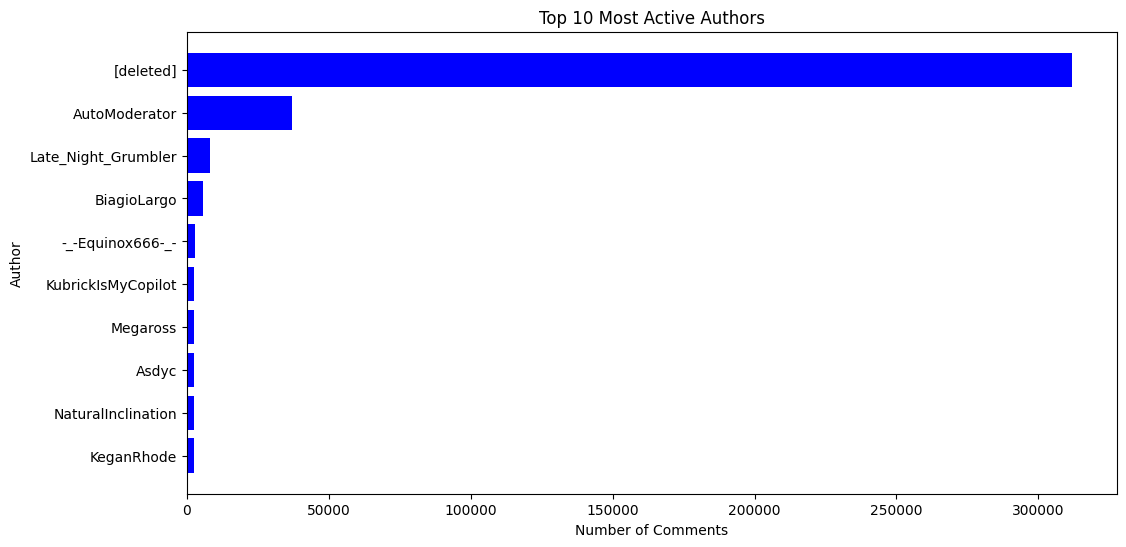

In [94]:
df = result.to_pandas()

plt.figure(figsize=(12,6))
plt.barh(df['AUTHOR'], df['NUM_COMMENTS'], color='blue')
plt.xlabel("Number of Comments")
plt.ylabel("Author")
plt.title("Top 10 Most Active Authors")
plt.gca().invert_yaxis()
plt.show()

11. Top 5 most controversial comments:

In [96]:
query = """
SELECT * FROM (
    SELECT 
        c.id, 
        c.body, 
        c.controversiality
    FROM 
        askreddit_comment c
    ORDER BY 
        c.controversiality DESC
) WHERE ROWNUM <= 5
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (5, 3)
┌─────────┬─────────────────────────────────┬──────────────────┐
│ ID      ┆ BODY                            ┆ CONTROVERSIALITY │
│ ---     ┆ ---                             ┆ ---              │
│ str     ┆ object                          ┆ i64              │
╞═════════╪═════════════════════════════════╪══════════════════╡
│ cqug921 ┆ I honestly wouldn't have belie… ┆ 1                │
│ cquga7v ┆ &gt; People interpret the Bibl… ┆ 1                │
│ cqug9ki ┆ WHITE CIS MALES CAN'T BE OPPRE… ┆ 1                │
│ cqug95f ┆ You're just trying to get to t… ┆ 1                │
│ cqug94y ┆ The implications of that varie… ┆ 1                │
└─────────┴─────────────────────────────────┴──────────────────┘


This query retrieves the top 10 most controversial comments by sorting them in descending order based on their controversiality score. It uses ROWNUM <= 5 to limit the results to the first 5 rows after ordering.

12. Top 5 most upvoted comments:

In [97]:
query = """
SELECT 
    c.id, 
    c.body, 
    s.ups
FROM 
    askreddit_comment c
JOIN 
    askreddit_score s ON c.id = s.id
ORDER BY 
    s.ups DESC
FETCH FIRST 5 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (5, 3)
┌─────────┬─────────────────────────────────┬──────┐
│ ID      ┆ BODY                            ┆ UPS  │
│ ---     ┆ ---                             ┆ ---  │
│ str     ┆ object                          ┆ i64  │
╞═════════╪═════════════════════════════════╪══════╡
│ cr56nez ┆ Then you got yourself a one ni… ┆ 6761 │
│ cr5gn52 ┆ if it's untreated wood...       ┆ 6736 │
│         ┆                                 ┆      │
│         ┆ cut…                            ┆      │
│ cr3imvn ┆ I have family who sailed aroun… ┆ 5992 │
│ cr8p5z9 ┆ My boss is this giddy Asian la… ┆ 5927 │
│ cqxx3fj ┆ Thanks man and also fuck you m… ┆ 5849 │
└─────────┴─────────────────────────────────┴──────┘


This query fetches the top 5 most upvoted comments, joining askreddit_comment with askreddit_score to access the ups column. It orders comments in descending order of upvotes and limits the results using FETCH FIRST 5 ROWS ONLY.

13. Top 5 most downvoted comments:

In [95]:
query = """
SELECT 
    c.id, 
    c.body, 
    s.downs
FROM 
    askreddit_comment c
JOIN 
    askreddit_score s ON c.id = s.id
ORDER BY 
    s.downs DESC
FETCH FIRST 5 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (5, 3)
┌─────────┬─────────────────────────────────┬───────┐
│ ID      ┆ BODY                            ┆ DOWNS │
│ ---     ┆ ---                             ┆ ---   │
│ str     ┆ object                          ┆ i64   │
╞═════════╪═════════════════════════════════╪═══════╡
│ cqug90z ┆ NSFL                            ┆ 0     │
│ cqug91c ┆ I'm a guy and I had no idea th… ┆ 0     │
│ cqug91e ┆ Mid twenties male rocking skin… ┆ 0     │
│ cqug920 ┆ Fran Drescher laughing          ┆ 0     │
│ cqug929 ┆ no money, just ID, driver lice… ┆ 0     │
└─────────┴─────────────────────────────────┴───────┘


This query retrieves the top 5 most downvoted comments, similar to the upvotes query, but sorting by downs in descending order. It helps identify the comments that received the most negative reactio

## Part 4: Detailed exploration of the database

1. Top 5 Daily Comment Trends and Average Scores

In [40]:
query = """
SELECT TRUNC(c.created_utc) AS comment_date,
       COUNT(*) AS num_comments,
       AVG(s.score) AS avg_score
FROM askreddit_comment c
JOIN askreddit_score s ON c.id = s.id
GROUP BY TRUNC(c.created_utc)
ORDER BY avg_score desc
FETCH FIRST 5 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (5, 3)
┌──────────────┬──────────────┬───────────┐
│ COMMENT_DATE ┆ NUM_COMMENTS ┆ AVG_SCORE │
│ ---          ┆ ---          ┆ ---       │
│ i64          ┆ i64          ┆ i64       │
╞══════════════╪══════════════╪═══════════╡
│ 1431590139   ┆ 1            ┆ 5927      │
│ 1430746080   ┆ 1            ┆ 5849      │
│ 1431351418   ┆ 1            ┆ 5767      │
│ 1432394619   ┆ 1            ┆ 5741      │
│ 1430547586   ┆ 1            ┆ 5699      │
└──────────────┴──────────────┴───────────┘


This query aggregates comments by day, showing both the total number of comments and the average score per day.

It uses Oracle’s TRUNC function to group comments by date (ignoring time) and then calculates daily counts and average scores, helping you analyze trends over time.

2. Top Authors by Average Score (Minimum 100 Comments)

In [42]:
query = """
SELECT a.author,
       COUNT(*) AS num_comments,
       AVG(s.score) AS avg_score
FROM askreddit_comment c
JOIN askreddit_score s ON c.id = s.id
JOIN askreddit_author a ON c.author = a.author
GROUP BY a.author
HAVING COUNT(*) > 100
ORDER BY avg_score DESC
FETCH FIRST 10 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 3)
┌───────────────────┬──────────────┬────────────┐
│ AUTHOR            ┆ NUM_COMMENTS ┆ AVG_SCORE  │
│ ---               ┆ ---          ┆ ---        │
│ str               ┆ i64          ┆ f64        │
╞═══════════════════╪══════════════╪════════════╡
│ Donald_Keyman     ┆ 312          ┆ 728.125    │
│ here_for_the_lols ┆ 130          ┆ 393.376923 │
│ CuntyMcGiggles    ┆ 156          ┆ 312.935897 │
│ anotherpoweruser  ┆ 113          ┆ 266.318584 │
│ shinydragonite    ┆ 114          ┆ 228.149123 │
│ temtam            ┆ 130          ┆ 221.469231 │
│ FoieyMcfoie       ┆ 289          ┆ 187.235294 │
│ techniforus       ┆ 146          ┆ 175.30137  │
│ Itanagon          ┆ 174          ┆ 173.862069 │
│ DrAminove         ┆ 136          ┆ 168.308824 │
└───────────────────┴──────────────┴────────────┘


By grouping comments by author and filtering for those with more than 100 comments, this query highlights the most consistently high-performing authors in terms of average score.

3. Most Replied-to (Parent) Posts

In [44]:
query = """
SELECT p.parent_id AS parent_id, COUNT(*) AS num_replies
FROM askreddit_depends d
JOIN askreddit_parent p ON d.parent_id = p.parent_id
GROUP BY p.parent_id
ORDER BY num_replies DESC
FETCH FIRST 10 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 2)
┌───────────┬─────────────┐
│ PARENT_ID ┆ NUM_REPLIES │
│ ---       ┆ ---         │
│ str       ┆ i64         │
╞═══════════╪═════════════╡
│ t3_37pr7d ┆ 30771       │
│ t3_37c2p3 ┆ 11546       │
│ t3_36ih74 ┆ 10981       │
│ t3_365rlk ┆ 7703        │
│ t3_364iu2 ┆ 7558        │
│ t3_36959m ┆ 5976        │
│ t3_35ycya ┆ 5602        │
│ t3_36vidd ┆ 5249        │
│ t3_37himl ┆ 5129        │
│ t3_370ppy ┆ 4892        │
└───────────┴─────────────┘


This query shows which parent posts have the most replies by counting the number of dependent comments for each parent.
It counts replies per parent post, revealing which posts sparked the most discussion.

4. Controversial Comments with High Scores

In [46]:
query = """
SELECT c.id, c.body, c.controversiality, s.score
FROM askreddit_comment c
JOIN askreddit_score s ON c.id = s.id
WHERE c.controversiality > 0
ORDER BY c.controversiality DESC, s.score DESC
FETCH FIRST 5 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (5, 4)
┌─────────┬─────────────────────────────────┬──────────────────┬───────┐
│ ID      ┆ BODY                            ┆ CONTROVERSIALITY ┆ SCORE │
│ ---     ┆ ---                             ┆ ---              ┆ ---   │
│ str     ┆ object                          ┆ i64              ┆ i64   │
╞═════════╪═════════════════════════════════╪══════════════════╪═══════╡
│ cr3xezy ┆ This is actually an incredible… ┆ 1                ┆ 1780  │
│ crcu53z ┆ Correction, McFly, we haven't … ┆ 1                ┆ 1260  │
│ cr2ujc9 ┆ I was an attendant on a red ey… ┆ 1                ┆ 496   │
│ cr2ulwz ┆ Flight attendant for a domesti… ┆ 1                ┆ 469   │
│ cr40bz3 ┆ Hi...4th time's the charm?      ┆ 1                ┆ 422   │
└─────────┴─────────────────────────────────┴──────────────────┴───────┘


This query filters for comments with a nonzero controversiality flag and orders them by controversiality and score. This helps pinpoint discussions that sparked strong reactions.

5. Upvotes vs. Downvotes by Subreddit

In [47]:
query = """
SELECT s.subreddit, 
       SUM(scor.ups) AS total_ups, 
       SUM(scor.downs) AS total_downs
FROM askreddit_comment c
JOIN askreddit_score scor ON c.id = scor.id
JOIN askreddit_subreddit s ON c.subreddit_id = s.subreddit_id
GROUP BY s.subreddit
ORDER BY total_ups DESC
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (1, 3)
┌───────────┬───────────┬─────────────┐
│ SUBREDDIT ┆ TOTAL_UPS ┆ TOTAL_DOWNS │
│ ---       ┆ ---       ┆ ---         │
│ str       ┆ i64       ┆ i64         │
╞═══════════╪═══════════╪═════════════╡
│ AskReddit ┆ 53386979  ┆ 0           │
└───────────┴───────────┴─────────────┘


This query aggregates the total number of upvotes and downvotes for comments in each subreddit.
It joins comments, scores, and subreddits to calculate overall community sentiment per subreddit, which can reveal where the audience is most engaged.

6. Average Comment Length per Author

In [52]:
query = """
SELECT a.author, 
       AVG(LENGTH(c.body)) AS avg_length
FROM askreddit_comment c
JOIN askreddit_author a ON c.author = a.author
GROUP BY a.author
HAVING AVG(LENGTH(c.body)) IS NOT NULL
ORDER BY avg_length DESC
FETCH FIRST 10 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (10, 2)
┌─────────────────────┬────────────┐
│ AUTHOR              ┆ AVG_LENGTH │
│ ---                 ┆ ---        │
│ str                 ┆ i64        │
╞═════════════════════╪════════════╡
│ Throaway92746281    ┆ 9991       │
│ onewisegoat         ┆ 9987       │
│ throwaway8971876541 ┆ 9852       │
│ hopeshewas18        ┆ 9751       │
│ wiggleshuffle       ┆ 9353       │
│ juthonce            ┆ 9319       │
│ whatsahottytoddy    ┆ 8868       │
│ DaleJrfan88         ┆ 8719       │
│ monkeytoes21        ┆ 8653       │
│ BobTehCat           ┆ 8556       │
└─────────────────────┴────────────┘


This query calculates the average length (in characters) of comments for each author and shows the top 10 authors with the longest average comment length.It uses the Oracle LENGTH function on the comment text to compute average comment length per author. This query can help identify verbose contributors.

7. Full‐Text Search for Positive Sentiment

In [58]:
query = """
SELECT id, body
FROM askreddit_comment
WHERE body LIKE '%good%' 
   OR body LIKE '%great%' 
   OR body LIKE '%excellent%'
ORDER BY created_utc DESC
FETCH FIRST 5 ROWS ONLY
"""
result = pl.read_database(query, oradb_cursor)
print(result)


shape: (5, 2)
┌─────────┬─────────────────────────────────┐
│ ID      ┆ BODY                            │
│ ---     ┆ ---                             │
│ str     ┆ object                          │
╞═════════╪═════════════════════════════════╡
│ crrbel1 ┆ That's a good way to get pulle… │
│ crrbeb6 ┆ HIMYM. Seasons 1 through 4 wer… │
│ crrbe1u ┆ Sure. Remember a "lightsaber" … │
│ crrbd8j ┆ Gonna guess that merchandising… │
│ crrbchu ┆ **PLEASE READ THIS MESSAGE IN … │
└─────────┴─────────────────────────────────┘


This query uses Oracle Text’s CONTAINS function to search for comments that include words like "good", "great", or "excellent." It then orders the results by creation date.

8. Combining NLP with Temporal Analysis

In [77]:
create_index_query = """
CREATE INDEX idx_body_text ON askreddit_comment (body) INDEXTYPE IS CTXSYS.CONTEXT
"""
oradb_cursor.execute(create_index_query)

In [80]:
query = """
SELECT TRUNC(created_utc) AS comment_date,
       COUNT(*) AS num_comments_containing_bad
FROM askreddit_comment
WHERE CONTAINS(body, 'bad', 1) > 0
GROUP BY TRUNC(created_utc)
ORDER BY num_comments_containing_bad desc, comment_date
"""
result = pl.read_database(query, oradb_cursor)
print(result)

shape: (75_669, 2)
┌──────────────┬─────────────────────────────┐
│ COMMENT_DATE ┆ NUM_COMMENTS_CONTAINING_BAD │
│ ---          ┆ ---                         │
│ i64          ┆ i64                         │
╞══════════════╪═════════════════════════════╡
│ 1430949121   ┆ 3                           │
│ 1431029720   ┆ 3                           │
│ 1431047195   ┆ 3                           │
│ 1431538735   ┆ 3                           │
│ 1431544375   ┆ 3                           │
│ …            ┆ …                           │
│ 1433116678   ┆ 1                           │
│ 1433116706   ┆ 1                           │
│ 1433116708   ┆ 1                           │
│ 1433116709   ┆ 1                           │
│ 1433116723   ┆ 1                           │
└──────────────┴─────────────────────────────┘


This query groups comments by date (ignoring time) and counts only those comments whose body contains the term “bad.” It can reveal daily trends in discussions or support requests.

## Part 5: Subset of the database

In a fifth step, using part of the data, you will create a smaller version of the database. This 
database file will be handed-in. The absolute limit in terms of database file size is 5MB. 
Select the data wisely and explain how you selected the data, why it is a relevant subset as a 
whole. 
Provide in the report the process (schema and SQL code) on how this subset was built, i.e. the 
queries that were required—if different from queries presented in previous steps—to detect 
the data subset (for example, if you would want to select events linked to specific users, how 
those “specific” users were defined and how they were detected with SQL queries). 

### When everything is done, we can close the Oracle connection.

In [ ]:
# Close the connection
oradb_connection.close()